In [1]:
import os

from torchvision.transforms import transforms
from torch.utils.data import DataLoader , Dataset , random_split

import numpy as np
import matplotlib.pyplot as plt

#The pillow library is a fork of the Python Imaging Library (PIL) and provides support for opening, manipulating, and saving many different image file formats. It is widely used in image processing tasks, including computer vision and deep learning applications.
from PIL import Image

#Library that allows us to read .mat files
import scipy.io as sio

#Library that allows us to extract .tar files
import tarfile

#Library that allows us to download files from the internet
import requests as requests

#tqdm is a library that allows us to create progress bars for loops and other iterable objects. It is useful for tracking the progress of long-running tasks, such as downloading files or training machine learning models.
from tqdm.auto import tqdm

c:\Users\rasha\miniconda3\envs\AI-ML-3.12\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def download_dataset():
    """
    Downloads and extracts a dataset from remote URLs if not already present locally.

    This function first checks for the existence of the dataset files in a specific
    directory. If the files are not found, it proceeds to download them from
    pre-defined URLs, and then extracts the contents.
    """
    # Define the directory to store the dataset.
    data_dir = "./../../data/oxford102"
    
    # Define paths for key files and folders.
    image_folder_path = os.path.join(data_dir, "jpg")
    labels_file_path = os.path.join(data_dir, "imagelabels.mat")
    tgz_path = os.path.join(data_dir, "102flowers.tgz")

    # Check if the primary data folder and a key label file already exist.
    if os.path.exists(image_folder_path) and os.path.exists(labels_file_path):
        # Inform that the dataset is already available locally.
        print(f"Dataset already exists. Loading locally from '{data_dir}'.")
        # Exit the function since no download is needed.
        return

    # Inform that the dataset is not found and the download will start.
    print("Dataset not found locally. Downloading...")

    # Define the URLs for the image archive and the labels file.
    image_url = "https://www.robots.ox.ac.uk/~vgg/data/flowers/102/102flowers.tgz"
    labels_url = "https://www.robots.ox.ac.uk/~vgg/data/flowers/102/imagelabels.mat"

    # Create the target directory for the dataset, if it doesn't already exist.
    os.makedirs(data_dir, exist_ok=True)

    # Announce the start of the image download process.
    print("Downloading images...")
    # Send an HTTP GET request to the image URL, enabling streaming for large files.
    response = requests.get(image_url, stream=True)
    # Get the total size of the file from the response headers for the progress bar.
    total_size = int(response.headers.get("content-length", 0))

    # Open a local file in binary write mode to save the downloaded archive.
    with open(tgz_path, "wb") as file:
        # Iterate over the response content in chunks with a progress bar.
        for data in tqdm(
            # Define the chunk size for iterating over the content.
            response.iter_content(chunk_size=1024),
            # Set the total for the progress bar based on the file size in kilobytes.
            total=total_size // 1024,
        ):
            # Write each chunk of data to the file.
            file.write(data)

    # Announce the start of the file extraction process.
    print("Extracting files...")
    # Open the downloaded tar.gz archive in read mode.
    with tarfile.open(tgz_path, "r:gz") as tar:
        # Extract all contents of the archive into the target directory.
        tar.extractall(data_dir)

    # Announce the start of the labels download process.
    print("Downloading labels...")
    # Send an HTTP GET request to the labels URL.
    response = requests.get(labels_url)
    # Open a local file in binary write mode to save the labels.
    with open(labels_file_path, "wb") as file:
        # Write the entire content of the response to the file.
        file.write(response.content)

    # Inform the user that the download and extraction are complete.
    print(f"Dataset downloaded and extracted to '{data_dir}'.")

In [3]:
def create_labels_description(data_dir):
     # create labels_description.txt
        labels_description = [
            'pink primrose', 'hard-leaved pocket orchid', 'canterbury bells', 'sweet pea', 'english marigold', 'tiger lily',
            'moon orchid', 'bird of paradise', 'monkshood', 'globe thistle', 'snapdragon', "colt's foot", 'king protea',
            'spear thistle', 'yellow iris', 'globe-flower', 'purple coneflower', 'peruvian lily', 'balloon flower',
            'giant white arum lily', 'fire lily', 'pincushion flower', 'fritillary', 'red ginger', 'grape hyacinth',
            'corn poppy', 'prince of wales feathers', 'stemless gentian', 'artichoke', 'sweet william', 'carnation',
            'garden phlox', 'love in the mist', 'mexican aster', 'alpine sea holly', 'ruby-lipped cattleya', 'cape flower',
            'great masterwort', 'siam tulip', 'lenten rose', 'barbeton daisy', 'daffodil', 'sword lily', 'poinsettia',
            'bolero deep blue', 'wallflower', 'marigold', 'buttercup', 'oxeye daisy', 'common dandelion', 'petunia',
            'wild pansy', 'primula', 'sunflower', 'pelargonium', 'bishop of llandaff', 'gaura', 'geranium', 'orange dahlia',
            'pink-yellow dahlia?', 'cautleya spicata', 'japanese anemone', 'black-eyed susan', 'silverbush', 'californian poppy',
            'osteospermum', 'spring crocus', 'bearded iris', 'windflower', 'tree poppy', 'gazania', 'azalea', 'water lily',
            'rose', 'thorn apple', 'morning glory', 'passion flower', 'lotus', 'toad lily', 'anthurium', 'frangipani',
            'clematis', 'hibiscus', 'columbine', 'desert-rose', 'tree mallow', 'magnolia', 'cyclamen ', 'watercress',
            'canna lily', 'hippeastrum ', 'bee balm', 'ball moss', 'foxglove', 'bougainvillea', 'camellia', 'mallow',
            'mexican petunia', 'bromelia', 'blanket flower', 'trumpet creeper', 'blackberry lily'
        ]
    
        if not os.path.exists(data_dir):
            os.makedirs(data_dir)
        with open(os.path.join(data_dir, "labels_description.txt"), "w") as f:
            for idx, label in enumerate(labels_description, start=1):
                f.write(f"{label}\n")

In [4]:
path_dataset = "./../../data/oxford102"

In [5]:
# Call the function to download and prepare the dataset.
download_dataset()

Dataset already exists. Loading locally from './../../data/oxford102'.


In [6]:
#Call the function to create the labels description file.
create_labels_description("./../../data/oxford102")

In [7]:
# Define the dataset class 
class FlowerDataset(Dataset):
    
    def __init__(self, root_dir, transform=None):
        # Store the root directory path.
        self.root_dir = root_dir
        # Store the optional transformations.
        self.transform = transform
        # Construct the full path to the image directory.
        self.image_dir = os.path.join(self.root_dir, "jpg")
        # Load and process the labels from the corresponding file.
        self.labels = self.load_and_correct_labels()

    def __len__(self):
        total_samples = len(self.labels)
        # Return the total number of samples.
        return total_samples

    def __getitem__(self, idx):

        # Retrieve the image for the given index.
        image = self.retrieve_image(idx)

        # Check if a transform is provided.
        if self.transform is not None:
            # Apply the transform to the image.
            image = self.transform(image)

        # Get the label corresponding to the index.
        label = self.labels[idx]

        # Return the processed image and its label.
        return image, label

    def retrieve_image(self, idx):

        # Construct the image filename based on the index.
        img_name = f"image_{idx + 1:05d}.jpg"
        # Construct the full path to the image file.
        img_path = os.path.join(self.image_dir, img_name)
        # Open the image file.
        with Image.open(img_path) as img:
            # Convert the image to the RGB color space.
            image = img.convert("RGB")
        # Return the converted image.
        return image

    def load_and_correct_labels(self):

        # Load the file containing the labels.
        self.labels_mat = sio.loadmat(
            os.path.join(self.root_dir, "imagelabels.mat")
        )
        # Extract the labels array and correct for zero-based indexing.
        labels = self.labels_mat["labels"][0] - 1
        # Return the processed labels.
        return labels

    def get_label_description(self, label):

        path_labels_description = os.path.join(self.root_dir, "labels_description.txt")
        # Open the label description file for reading.
        with open(path_labels_description, "r") as f:
            # Read all lines from the file.
            lines = f.readlines()
        # Get the description for the specified label and remove leading/trailing whitespace.
        description = lines[label].strip()
        # Return the clean description.
        return description


In [8]:
# Initialize the dataset object, providing the path to the data.
dataset = FlowerDataset(path_dataset)

# Print the total number of samples in the dataset.
print(f'Number of samples in the dataset: {len(dataset)}')


Number of samples in the dataset: 8189


In [9]:
# Define an index for a sample to retrieve.
sel_idx = 10

# Retrieve the image and label for the selected index.
img, label = dataset[sel_idx]

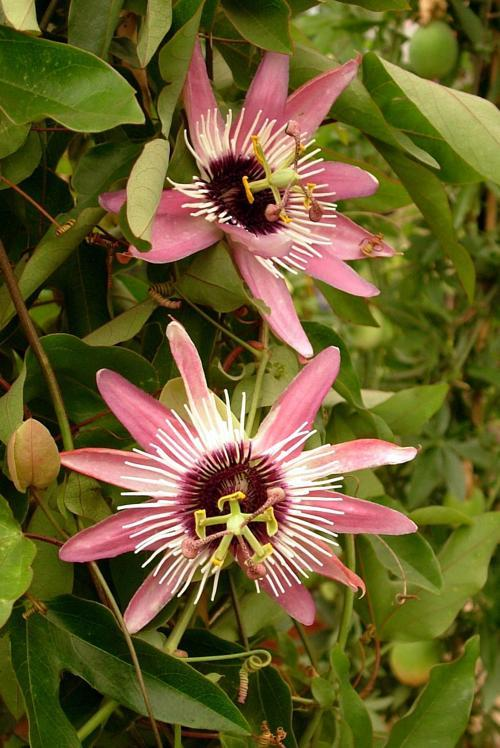

Image size: (500, 748), Label: 76


In [10]:
# Create a string detailing the image's dimensions.
img_size_info = f"Image size: {img.size}"

#display the image
display(img)

# Print the image size information along with its corresponding label.
print(f'{img_size_info}, Label: {label}')


In [11]:
# Get all labels from the dataset object.
dataset_labels = dataset.labels

# Create a set of unique labels to remove duplicates.
unique_labels = set(dataset_labels)

# Iterate through each unique label.
for label in unique_labels:
    # Print the numerical label and its corresponding text description.
    print(f'Label: {label}, Description: {dataset.get_label_description(label)}')

Label: 0, Description: pink primrose
Label: 1, Description: hard-leaved pocket orchid
Label: 2, Description: canterbury bells
Label: 3, Description: sweet pea
Label: 4, Description: english marigold
Label: 5, Description: tiger lily
Label: 6, Description: moon orchid
Label: 7, Description: bird of paradise
Label: 8, Description: monkshood
Label: 9, Description: globe thistle
Label: 10, Description: snapdragon
Label: 11, Description: colt's foot
Label: 12, Description: king protea
Label: 13, Description: spear thistle
Label: 14, Description: yellow iris
Label: 15, Description: globe-flower
Label: 16, Description: purple coneflower
Label: 17, Description: peruvian lily
Label: 18, Description: balloon flower
Label: 19, Description: giant white arum lily
Label: 20, Description: fire lily
Label: 21, Description: pincushion flower
Label: 22, Description: fritillary
Label: 23, Description: red ginger
Label: 24, Description: grape hyacinth
Label: 25, Description: corn poppy
Label: 26, Descript

In [12]:
def visual_exploration(dataset, num_rows=2, num_cols=4):
    """
    Displays a grid of randomly selected samples from the dataset for visual inspection.
    """
    # Calculate the total number of images to display in the grid.
    total_samples = num_rows * num_cols

    # Select a random set of unique indices from the dataset.
    indices = np.random.choice(len(dataset), total_samples, replace=False)

    # Create a grid of subplots to hold the images.
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 8))

    # Iterate over each subplot axis and the corresponding random sample index.
    for ax, idx in zip(axes.flatten(), indices):
        # Retrieve the image and its numerical label from the dataset.
        image, label = dataset[idx]

        # Get the human-readable text description for the label.
        description = dataset.get_label_description(label)

        # Format a new label string that includes both the number and description.
        label = f"{label} - {description}"

        # Create an information string with the sample's index and image dimensions.
        info = f"Index: {idx} Size: {image.size}"
        
        # Plot the image on the current subplot with its label and info.
        ax.imshow(image)
        ax.set_title(label, fontsize=10)

    # Render and display the entire grid of images.
    plt.show()

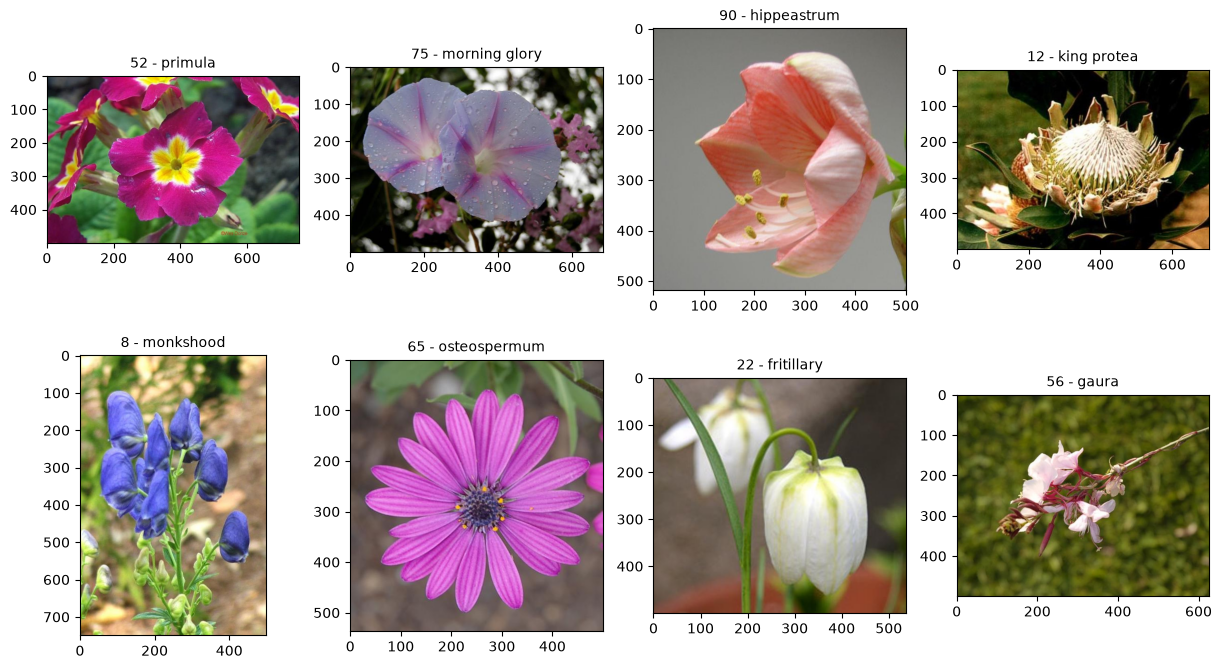

In [13]:
# Display a 2x4 grid of random samples from the dataset for visual inspection.
visual_exploration(dataset, num_rows=2, num_cols=4)

In [14]:
# Define the mean values for normalization.
mean = [0.485, 0.456, 0.406]
# Define the standard deviation values for normalization.
std = [0.229, 0.224, 0.225]

In [15]:
#Creating a transform pipeline

transform = transforms.Compose([
    #resize while keeping aspect ratio -> 256x256 images
    transforms.Resize(256,),

    #crop a square of 244x244 from the center of the images
    transforms.CenterCrop(244),

    #convert image to Pytorch tensor
    transforms.ToTensor(),

    #normalize values in tensor (z-score)
    transforms.Normalize(mean=mean , std=std)
])

original image


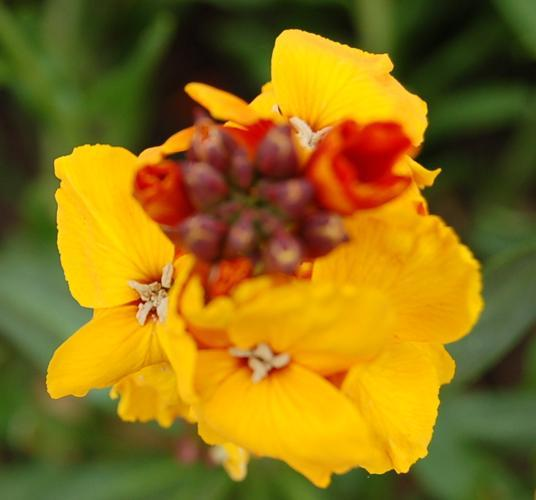

after resizing


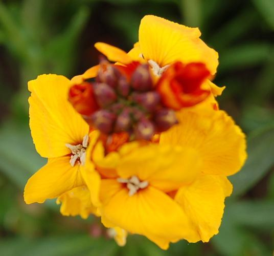

after cropping


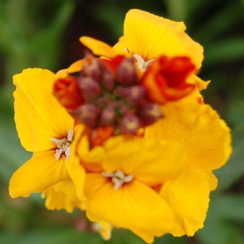

in tensor format
tensor([[[0.1961, 0.2000, 0.1961,  ..., 0.1490, 0.1686, 0.1882],
         [0.2118, 0.2078, 0.2039,  ..., 0.1333, 0.1569, 0.1804],
         [0.2078, 0.2000, 0.1922,  ..., 0.1373, 0.1529, 0.1686],
         ...,
         [0.3059, 0.3020, 0.3020,  ..., 0.2784, 0.2667, 0.2510],
         [0.3098, 0.3059, 0.3059,  ..., 0.2941, 0.2824, 0.2706],
         [0.3098, 0.3059, 0.3059,  ..., 0.3020, 0.2980, 0.2863]],

        [[0.2902, 0.2863, 0.2745,  ..., 0.2353, 0.2706, 0.3020],
         [0.3137, 0.3059, 0.2902,  ..., 0.2196, 0.2549, 0.2863],
         [0.3333, 0.3216, 0.3059,  ..., 0.2039, 0.2392, 0.2706],
         ...,
         [0.4157, 0.4196, 0.4196,  ..., 0.3765, 0.3647, 0.3490],
         [0.4196, 0.4196, 0.4235,  ..., 0.3843, 0.3725, 0.3608],
         [0.4196, 0.4235, 0.4235,  ..., 0.3804, 0.3804, 0.3725]],

        [[0.0510, 0.0510, 0.0510,  ..., 0.0549, 0.0627, 0.0784],
         [0.0627, 0.0588, 0.0588,  ..., 0.0431, 0.0510, 0.0745],
         [0.0667, 0.0706, 0.0706,  ..., 0

In [16]:
#Before applying transforms to the entire dataset , apply them first on a sample image
image , _ = dataset[1000]

print('original image')
display(image)

print('after resizing')
resized_image = transforms.Resize(256)(image)
display(resized_image)

print('after cropping')
cropped_image = transforms.CenterCrop(244)(resized_image)
display(cropped_image)

print('in tensor format')
image_tensor = transforms.ToTensor()(cropped_image)
print(image_tensor)

print('after scaling')
image_tensor_norm = transforms.Normalize(mean=[0.485 , 0.456 , 0.406] , std=[0.229 , 0.224 , 0.225])(image_tensor)
print(image_tensor_norm)


In [17]:
# Create a new dataset instance with the specified image transformations.
dataset_transformed = FlowerDataset(path_dataset, transform=transform)

In [18]:
# Retrieve the transformed image and its label using the same index.
img_transformed, label = dataset_transformed[sel_idx]

In [19]:
print(f'img_transformed: {img_transformed}')
print(f'img_transformed.shape: {img_transformed.shape}')
print(f'label: {label}')

img_transformed: tensor([[[-0.6452, -0.6281, -0.6623,  ...,  0.9474,  0.9132,  0.9132],
         [-0.6452, -0.6452, -0.6965,  ...,  0.8789,  0.8789,  0.8618],
         [-0.6281, -0.7137, -0.7479,  ...,  0.8276,  0.8276,  0.8104],
         ...,
         [-0.6281, -1.3302, -1.4500,  ..., -1.0562, -1.0562, -0.9534],
         [-1.1589, -1.7240, -1.7583,  ..., -1.1075, -1.2274, -1.2445],
         [-1.4843, -1.7754, -1.7925,  ..., -1.0733, -1.2959, -1.4329]],

        [[-0.2850, -0.2500, -0.2325,  ...,  1.1681,  1.1331,  1.0980],
         [-0.3025, -0.3025, -0.3200,  ...,  1.1331,  1.1155,  1.0805],
         [-0.3375, -0.4251, -0.4426,  ...,  1.0980,  1.0805,  1.0455],
         ...,
         [-0.3550, -1.0903, -1.1779,  ..., -0.8803, -0.8452, -0.7052],
         [-0.8627, -1.4230, -1.4930,  ..., -0.9503, -0.9678, -0.8627],
         [-1.1779, -1.4405, -1.4580,  ..., -0.8803, -1.0203, -1.0378]],

        [[-1.5953, -1.5604, -1.5779,  ..., -0.0615, -0.0615, -0.0790],
         [-1.5779, -1.5953, 

In [20]:
class Denormalize:
    """
    A callable class to reverse the normalization of a tensor image.

    This class calculates the inverse transformation of a standard normalization
    and can be used as a transform step, for instance, to visualize images
    after they have been normalized for a model.
    """
    def __init__(self, mean, std):
        """
        Initializes the denormalization transform.

        Args:
            mean (list or tuple): The mean values used for the original normalization.
            std (list or tuple): The standard deviation values used for the original normalization.
        """
        # Calculate the adjusted mean for the denormalization process.
        new_mean = [-m / s for m, s in zip(mean, std)]
        # Calculate the adjusted standard deviation for the denormalization process.
        new_std = [1 / s for s in std]
        # Create a Normalize transform object with the inverse parameters.
        self.denormalize = transforms.Normalize(mean=new_mean, std=new_std)

    def __call__(self, tensor):
        """
        Applies the denormalization transform to a tensor.

        Args:
            tensor (torch.Tensor): The normalized tensor to be denormalized.

        Returns:
            denormalized_tensor (torch.Tensor): The denormalized tensor.
        """
        # Apply the denormalization transform to the input tensor.
        denormalized_tensor = self.denormalize(tensor)
        
        # Return the denormalized tensor.
        return denormalized_tensor

In [21]:
# Create an instance of the Denormalize class with the original mean and std.
denormalize = Denormalize(mean=mean, std=std)

# Apply the denormalization transform to the image tensor.
img_tensor = denormalize(img_transformed)

# Create an information string with the tensor's shape.
img_shape_info = f"Image Shape: {img_tensor.size()}"

# show the denormalized image tensor to visualize the result.
img_tensor

tensor([[[0.3373, 0.3412, 0.3333,  ..., 0.7020, 0.6941, 0.6941],
         [0.3373, 0.3373, 0.3255,  ..., 0.6863, 0.6863, 0.6824],
         [0.3412, 0.3216, 0.3137,  ..., 0.6745, 0.6745, 0.6706],
         ...,
         [0.3412, 0.1804, 0.1529,  ..., 0.2431, 0.2431, 0.2667],
         [0.2196, 0.0902, 0.0824,  ..., 0.2314, 0.2039, 0.2000],
         [0.1451, 0.0784, 0.0745,  ..., 0.2392, 0.1882, 0.1569]],

        [[0.3922, 0.4000, 0.4039,  ..., 0.7176, 0.7098, 0.7020],
         [0.3882, 0.3882, 0.3843,  ..., 0.7098, 0.7059, 0.6980],
         [0.3804, 0.3608, 0.3569,  ..., 0.7020, 0.6980, 0.6902],
         ...,
         [0.3765, 0.2118, 0.1922,  ..., 0.2588, 0.2667, 0.2980],
         [0.2627, 0.1373, 0.1216,  ..., 0.2431, 0.2392, 0.2627],
         [0.1922, 0.1333, 0.1294,  ..., 0.2588, 0.2275, 0.2235]],

        [[0.0471, 0.0549, 0.0510,  ..., 0.3922, 0.3922, 0.3882],
         [0.0510, 0.0471, 0.0392,  ..., 0.3765, 0.3765, 0.3765],
         [0.0510, 0.0314, 0.0235,  ..., 0.3686, 0.3647, 0.

In [22]:
def split_dataset(dataset, val_fraction=0.15, test_fraction=0.15):
    """
    Splits a dataset into training, validation, and test sets.
    
    By default, this function partitions the data into 70% for training,
    15% for validation, and 15% for testing.

    Args:
        dataset (torch.utils.data.Dataset): The complete dataset to be split.
        val_fraction (float): The proportion of the dataset to reserve for validation.
        test_fraction (float): The proportion of the dataset to reserve for testing.

    Returns:
        train_dataset (torch.utils.data.Subset): The dataset split allocated for training.
        val_dataset (torch.utils.data.Subset): The dataset split allocated for validation.
        test_dataset (torch.utils.data.Subset): The dataset split allocated for testing.
    """

    # Calculate the total number of items in the dataset.
    total_size = len(dataset)
    
    # Calculate the number of items for the validation set.
    val_size = int(total_size * val_fraction)
    
    # Calculate the number of items for the test set.
    test_size = int(total_size * test_fraction)
    
    # Calculate the remaining number of items for the training set.
    train_size = total_size - val_size - test_size

    # Partition the dataset into the calculated sizes.
    train_dataset, val_dataset, test_dataset = random_split(
        dataset, [train_size, val_size, test_size]
    )
    
    # Return the resulting dataset partitions.
    return train_dataset, val_dataset, test_dataset

In [23]:
class SubsetWithTransform(Dataset):
    """
    A wrapper for a PyTorch Subset that applies a specific transformation.

    This class allows for applying a different set of transformations to a
    subset of a dataset, which is useful for creating distinct training,
    validation, or test sets with different preprocessing steps from the
    same base dataset.
    """
    def __init__(self, subset, transform=None):
        """
        Initializes the SubsetWithTransform object.

        Args:
            subset (torch.utils.data.Subset): A PyTorch Subset object containing a portion of a dataset.
            transform (callable, optional): An optional transform to be applied
                to the samples within this subset.
        """
        # Store the original subset of the dataset.
        self.subset = subset
        # Store the transformations to be applied.
        self.transform = transform

    def __len__(self):
        """
        Returns the total number of samples in the subset.

        Returns:
            subset_length (int): The total number of items in the subset.
        """
        # Calculate the length of the underlying subset.
        subset_length = len(self.subset)
        # Return the calculated length.
        return subset_length

    def __getitem__(self, idx):
        """
        Retrieves a sample and applies the transform.

        Args:
            idx (int): The index of the sample to retrieve.

        Returns:
            image (torch.Tensor or PIL.Image.Image): The transformed image.
            label (int): The corresponding label for the image.
        """
        # Get the original image and label from the underlying subset.
        image, label = self.subset[idx]
        
        # Check if a transform has been provided.
        if self.transform:
            # Apply the transform to the image.
            image = self.transform(image)
            
        # Return the transformed image and its label.
        return image, label

In [24]:
# Initialize the base dataset WITHOUT any transforms (returns PIL Images)
dataset_raw = FlowerDataset(path_dataset, transform=None)

# Split the raw dataset
train_subset, val_subset, test_subset = split_dataset(dataset_raw)

In [25]:
# Apply the basic preprocessing transform to all subsets for our initial baseline
train_dataset = SubsetWithTransform(train_subset, transform=transform)
val_dataset = SubsetWithTransform(val_subset, transform=transform)
test_dataset = SubsetWithTransform(test_subset, transform=transform)

In [26]:
print(f"Length of training dataset:   {len(train_dataset)}")
print(f"Length of validation dataset: {len(val_dataset)}")
print(f"Length of test dataset:       {len(test_dataset)}")

Length of training dataset:   5733
Length of validation dataset: 1228
Length of test dataset:       1228


In [28]:
# Set the batch size for the data loaders.
batch_size = 32

# Create the DataLoader for the training set, with shuffling enabled.
train_dataloader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)

# Create the DataLoader for the validation set, with shuffling disabled.
val_dataloader = DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=False)

# Create the DataLoader for the test set, with shuffling disabled.
test_dataloader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

In [29]:
# Define the total number of training epochs.
n_epochs = 2

In [30]:
# Start the main training loop for each epoch.
for epoch in range(n_epochs):
    # Print a header to indicate the start of a new epoch.
    print(f"\n=== Processing epoch {epoch} ===")

    # Announce the start of the training phase.
    print(f"Pass number {epoch} through the training set")
    print('\nTraining...')
    # Get the total number of samples in the training set.
    train_samples = len(train_dataset)


    # Create a progress bar for the training data loader.
    train_bar = tqdm(
        train_dataloader,
        total=len(train_dataloader),
        desc="Training",
        unit="batch"
    )
    
    # Iterate over the training data loader to get batches of images and labels.
    for batch, (images, labels) in enumerate(train_bar, start=1):
        train_bar.set_postfix(
            batch=f"{batch}/{len(train_dataloader)}",
            samples=f"{min(batch * batch_size, train_samples)}/{train_samples}"
        )

    # Announce the start of the validation phase.
    print(f"\nPass number {epoch} through the validation set")
    print('\nValidation...')
    # Create a progress bar for the validation data loader.
    val_bar = tqdm(
        val_dataloader,
        total=len(val_dataloader),
        desc="Validation",
        unit="batch"
    )
    # Get the total number of samples in the validation set.
    val_samples = len(val_dataset)
    
    # Iterate over the validation data loader to get batches of images and labels.
    for batch, (images, labels) in enumerate(val_bar, start=1):
        val_bar.set_postfix(
            batch=f"{batch}/{len(val_dataloader)}",
            samples=f"{min(batch * batch_size, val_samples)}/{val_samples}"
        )

print("\nTraining finished!\n")


=== Processing epoch 0 ===
Pass number 0 through the training set

Training...


Training: 100%|██████████| 180/180 [00:57<00:00,  3.15batch/s, batch=180/180, samples=5733/5733]



Pass number 0 through the validation set

Validation...


Validation: 100%|██████████| 39/39 [00:12<00:00,  3.04batch/s, batch=39/39, samples=1228/1228]



=== Processing epoch 1 ===
Pass number 1 through the training set

Training...


Training: 100%|██████████| 180/180 [00:54<00:00,  3.32batch/s, batch=180/180, samples=5733/5733]



Pass number 1 through the validation set

Validation...


Validation: 100%|██████████| 39/39 [00:11<00:00,  3.32batch/s, batch=39/39, samples=1228/1228]


Training finished!



In [31]:
# Announce the final evaluation on the test set.
print("Final pass through the test set for evaluation:\n")
# Create a progress bar for the test data loader.
test_bar = tqdm(
        test_dataloader,
        total=len(test_dataloader),
        desc="Test",
        unit="batch"
    )
# Get the total number of samples in the test set.
test_samples = len(test_dataset)

# Iterate over the test data loader to get batches of images and labels.
for batch, (images, labels) in enumerate(test_bar, start=1):
        test_bar.set_postfix(
            batch=f"{batch}/{len(test_dataloader)}",
            samples=f"{min(batch * batch_size, test_samples)}/{test_samples}"
        )

print("\nEvaluation finished!\n")

Final pass through the test set for evaluation:



Test: 100%|██████████| 39/39 [00:16<00:00,  2.31batch/s, batch=39/39, samples=1228/1228]


Evaluation finished!



In [32]:
def get_augmentation_transform(mean, std):
    """
    Creates and returns a composition of image transformations for data augmentation
    and preprocessing.

    Args:
        mean (list or tuple): A sequence of mean values for each channel.
        std (list or tuple): A sequence of standard deviation values for each channel.
    
    Returns:
        transform (torchvision.transforms.Compose): A composed pipeline of transformations.
    """
    # Define a list of data augmentation transformations to be applied randomly.
    augmentations_transforms = [
        # Randomly flip the image horizontally with a 50% probability.
        transforms.RandomHorizontalFlip(p=0.5),
        # Randomly rotate the image within a range of +/- 10 degrees.
        transforms.RandomRotation(degrees=10),
        # Randomly adjust the brightness of the image.
        transforms.ColorJitter(brightness=0.2),
    ]
    
    # Define the main list of standard, non-random transformations.
    main_transforms = [
        # Resize the input image to 256x256 pixels.
        transforms.Resize((256, 256)),
        # Crop the center 224x224 pixels of the image.
        transforms.CenterCrop(224),
        # Convert the PIL Image to a PyTorch tensor.
        transforms.ToTensor(),
        # Normalize the tensor with the provided mean and standard deviation.
        transforms.Normalize(mean=mean, std=std),
    ]

    # Combine the augmentation and main transformations into a single pipeline.
    transform = transforms.Compose(augmentations_transforms + main_transforms)
    
    # Return the final composed transform object.
    return transform

In [33]:
# Create the augmentation and preprocessing pipeline, providing the normalization stats.
augmentation_transform = get_augmentation_transform(mean=mean, std=std)

# Initialize a new dataset instance that will use the augmentation pipeline.
dataset_augmented = FlowerDataset(path_dataset, transform=augmentation_transform)

In [35]:
def visualize_augmentations(dataset_aug, idx=0, num_versions=8):
    """
    Displays multiple augmented versions of a single image from a dataset.

    Args:
        dataset_aug (torch.utils.data.Dataset): The dataset object with augmentation transforms applied.
        idx (int): The index of the image in the dataset to visualize.
        num_versions (int): The total number of augmented versions to display.
    """
    # Create a denormalization transform to revert normalization for display.
    denormalize = Denormalize(mean, std)

    # Set the number of rows for the visualization grid.
    n_rows = 2
    
    # Calculate the number of columns needed based on the total versions to show.
    n_cols = num_versions // n_rows
    
    # Create a grid of subplots to display the images.
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(16, 8),
        squeeze=False
    )

    # Iterate through each subplot axis in the grid.
    for version, ax in enumerate(axes.flatten()):
        if version < num_versions:
            img, label = dataset_aug[idx]

            # Convert CHW tensor to HWC format for Matplotlib.
            img = denormalize(img).permute(1, 2, 0).numpy()

            # Keep pixel values valid for display.
            img = np.clip(img, 0, 1)

            ax.imshow(img)
            ax.set_title(f"Version {version + 1}")
        else:
            ax.axis("off")

        ax.axis("off")

    fig.tight_layout()
    plt.show()

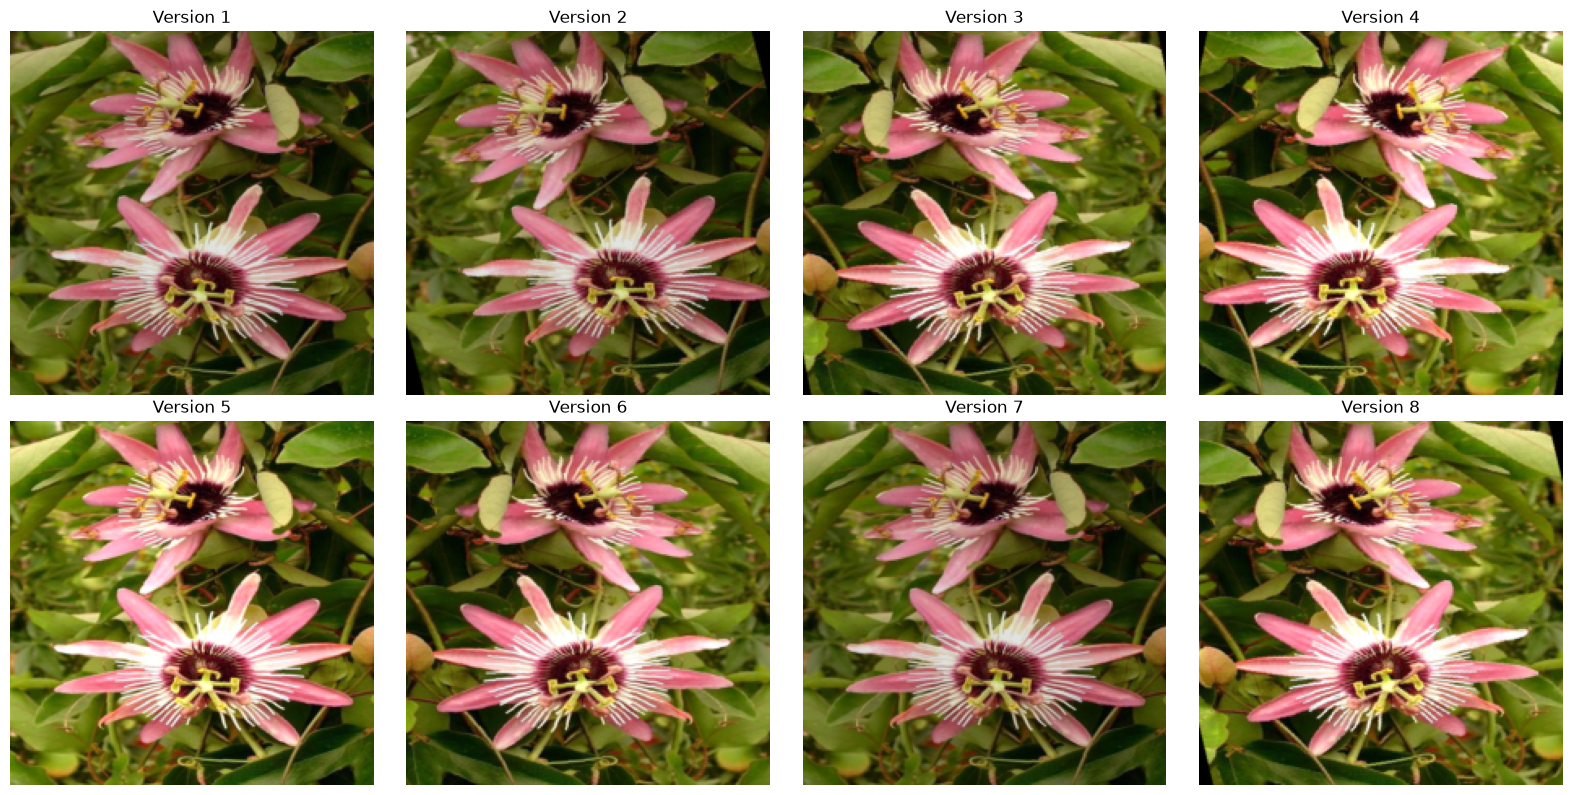

In [37]:
# Display 8 augmented versions of the selected image to see the transformations.
visualize_augmentations(dataset_augmented, idx=sel_idx, num_versions=8)

In [38]:
# apply the specific augmentation pipeline to the training subset
# Val and test subsets remain with the base preprocessing transform applied earlier
train_dataset = SubsetWithTransform(train_subset, transform=augmentation_transform)

In [39]:
print(train_dataset.transform)
print(val_dataset.transform)
print(test_dataset.transform)

Compose(
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.8, 1.2), contrast=None, saturation=None, hue=None)
    Resize(size=(256, 256), interpolation=bilinear, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)
Compose(
    Resize(size=256, interpolation=bilinear, max_size=None, antialias=True)
    CenterCrop(size=(244, 244))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)
Compose(
    Resize(size=256, interpolation=bilinear, max_size=None, antialias=True)
    CenterCrop(size=(244, 244))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [41]:
class RobustFlowerDataset(Dataset):
    """
    A custom dataset class with robust error handling for loading images.

    This class is designed to gracefully handle issues with individual data
    samples, such as corrupted files or incorrect formats. It logs any errors
    and attempts to load a different sample instead of crashing.
    """
    def __init__(self, root_dir, transform=None):
        """
        Initializes the dataset object.

        Args:
            root_dir (str): The root directory where the dataset is stored.
            transform (callable, optional): Optional transform to be applied
                on a sample.
        """
        # Store the root directory path.
        self.root_dir = root_dir
        # Construct the full path to the image directory.
        self.img_dir = os.path.join(root_dir, "jpg")
        # Store the optional transformations.
        self.transform = transform
        # Load and process the labels from the corresponding file.
        self.labels = self.load_and_correct_labels()
        # Initialize a list to keep track of any errors encountered.
        self.error_logs = []

    def __getitem__(self, idx):
        """
        Retrieves a sample, handling errors by trying the next available item.

        Args:
            idx (int): The index of the sample to retrieve.

        Returns:
            image (PIL.Image.Image or torch.Tensor): The processed image data.
            label (int): The corresponding label for the image.
        """
        # Loop to attempt loading a valid sample, preventing an infinite loop.
        for attempt in range(len(self)):
            # Attempt to load and process the sample.
            try:
                # Retrieve the image using the helper method.
                image = self.retrieve_image(idx)
                # Check if a transform has been provided.
                if self.transform:
                    # Apply the transform to the image.
                    image = self.transform(image)
                # Get the label for the current index.
                label = self.labels[idx]
                # Return the valid image and its corresponding label.
                return image, label
            # Catch any exception that occurs during the process.
            except Exception as e:
                # Log the error with its index and message.
                self.log_error(idx, e)
                # Move to the next index, wrapping around if necessary.
                idx = (idx + 1) % len(self)

    def __len__(self):
        """
        Returns the total number of samples in the dataset.

        Returns:
            total_samples (int): The total number of items in the dataset.
        """
        # The total number of samples is the number of labels.
        total_samples = len(self.labels)
        # Return the calculated length.
        return total_samples

    def retrieve_image(self, idx):
        """
        Loads and validates a single image from disk.

        Args:
            idx (int): The index of the image to load.

        Returns:
            image (PIL.Image.Image): The validated and loaded image object.
        """
        # Construct the image filename based on the index.
        img_name = f"image_{idx+1:05d}.jpg"
        # Construct the full path to the image file.
        img_path = os.path.join(self.img_dir, img_name)
        # Open the image file to check its integrity without loading fully.
        with Image.open(img_path) as img:
            # Perform a quick verification of the file's structure.
            img.verify()
        # Re-open the image file after successful verification.
        image = Image.open(img_path)
        # Fully load the image data into memory.
        image.load()
        # Check if the image dimensions are below a minimum threshold.
        if image.size[0] < 32 or image.size[1] < 32:
            # Raise an error for images that are too small.
            raise ValueError(f"Image too small: {image.size}")
        # Check if the image is not in the RGB color mode.
        if image.mode != "RGB":
            # Convert the image to RGB.
            image = image.convert("RGB")
        # Return the fully loaded and validated image.
        return image

    def load_and_correct_labels(self):
        """
        Loads labels from a file and adjusts them.

        Returns:
            labels (numpy.ndarray): An array of zero-indexed integer labels.
        """
        # Load the file containing the labels.
        self.labels_mat = sio.loadmat(
            os.path.join(self.root_dir, "imagelabels.mat")
        )
        # Extract the labels array and correct for zero-based indexing.
        labels = self.labels_mat["labels"][0] - 1
        # Truncate the dataset to the first 10 labels for quick testing.
        labels = labels[:10]
        # Return the processed labels.
        return labels

    def log_error(self, idx, e):
        """
        Records the details of an error encountered during data loading.

        Args:
            idx (int): The index of the problematic sample.
            e (Exception): The exception object that was raised.
        """
        # Construct the filename of the problematic image.
        img_name = f"image_{idx + 1:05d}.jpg"
        # Construct the full path to the image file.
        img_path = os.path.join(self.img_dir, img_name)
        # Append a dictionary with error details to the log.
        self.error_logs.append(
            {
                "index": idx,
                "error": str(e),
                "path": img_path if "img_path" in locals() else "unknown",
            }
        )
        # Print a warning to the console about the skipped image.
        print(f"Warning: Skipping corrupted image {idx}: {e}")

    def get_error_summary(self):
        """
        Prints a summary of all errors encountered during dataset processing.
        """
        # Check if the error log is empty.
        if not self.error_logs:
            # Print a message indicating the dataset is clean.
            print("No errors encountered - dataset is clean!")
        else:
            # Print the total number of problematic images found.
            print(f"\nEncountered {len(self.error_logs)} problematic images:")
            # Iterate through the first few logged errors.
            for error in self.error_logs[:5]:
                # Print the details of an individual error.
                print(f"  Index {error['index']}: {error['error']}")
            # Check if there are more errors than were displayed.
            if len(self.error_logs) > 5:
                # Print a summary of the remaining errors.
                print(f"  ... and {len(self.error_logs) - 5} more")

In [42]:
class MonitoredDataset(RobustFlowerDataset):
    """
    Extends a robust dataset class to add performance monitoring.

    This class tracks metrics such as how frequently each image is accessed,
    how long each access takes, and which images are never loaded. It provides
    a summary of these statistics to help diagnose data pipeline issues.
    """
    def __init__(self, *args, **kwargs):
        """
        Initializes the monitored dataset object.

        Args:
            *args (tuple): Variable length argument list passed to the parent class.
            **kwargs (dict): Arbitrary keyword arguments passed to the parent class.
        """
        # Initialize the parent class with all provided arguments.
        super().__init__(*args, **kwargs)
        # Initialize a dictionary to count how many times each index is accessed.
        self.access_counts = {}
        # Initialize a list to store the load time for each access.
        self.load_times = []

    def __getitem__(self, idx):
        """
        Retrieves a sample while monitoring access counts and load times.

        Args:
            idx (int): The index of the sample to retrieve.

        Returns:
            result (tuple): The data sample (e.g., image and label) from the parent class.
        """
        # Import the time module for timing operations.
        import time
        # Record the start time of the operation.
        start_time = time.time()
        # Increment the access count for the given index.
        self.access_counts[idx] = self.access_counts.get(idx, 0) + 1
        # Call the parent class's method to load the data.
        result = super().__getitem__(idx)
        # Calculate the total time taken to load the sample.
        load_time = time.time() - start_time
        # Append the calculated load time to the list.
        self.load_times.append(load_time)
        # Check if the load time exceeds a certain threshold.
        if load_time > 1.0:
            # Print a warning if a slow load time is detected.
            print(f"⚠️ Slow load: Image {idx} took {load_time:.2f}s")
        # Return the loaded sample from the parent class.
        return result

    def print_stats(self):
        """
        Prints a summary of the dataset's access statistics and performance.
        """
        # Print a header for the statistics report.
        print("\n=== Pipeline Statistics ===")
        # Display the total number of images in the dataset.
        print(f"Total images: {len(self)}")
        # Display the number of unique images that were accessed.
        print(f"Unique images accessed: {len(self.access_counts)}")
        # Display the total number of errors logged by the parent class.
        print(f"Errors encountered: {len(self.error_logs)}")
        # Check if any load times have been recorded.
        if self.load_times:
            # Calculate the average load time.
            avg_time = sum(self.load_times) / len(self.load_times)
            # Find the maximum (slowest) load time.
            max_time = max(self.load_times)
            # Print the average load time in milliseconds.
            print(f"Average load time: {avg_time*1000:.1f} ms")
            # Print the slowest load time in milliseconds.
            print(f"Slowest load: {max_time*1000:.1f} ms")
        # Create a set of all possible indices in the dataset.
        all_indices = set(range(len(self)))
        # Create a set of all indices that were actually accessed.
        accessed_indices = set(self.access_counts.keys())
        # Find the set of indices that were never accessed.
        never_accessed = all_indices - accessed_indices
        # Check if there are any images that were never loaded.
        if never_accessed:
            # Print a warning message with the count of never-accessed images.
            print(f"\n⚠️ WARNING: {len(never_accessed)} images were never loaded!")
            # Show a few examples of the indices that were never accessed.
            print(f"   Examples: {list(never_accessed)[:5]}")

In [44]:
# Initialize the monitored dataset with the path to the potentially corrupted data.
monitored_dataset = MonitoredDataset(path_dataset)

# Loop through every index in the dataset to simulate a full pass.
# Iterate through the dataset to trigger monitoring
for idx in range(len(monitored_dataset)):
    # Access the sample at the current index to trigger the monitoring and error-handling logic.
    img, label = monitored_dataset[idx]

In [45]:
# Print the statistics
monitored_dataset.print_stats()


=== Pipeline Statistics ===
Total images: 10
Unique images accessed: 10
Errors encountered: 0
Average load time: 32.5 ms
Slowest load: 157.0 ms
